# Preprocessing of Data sources

This notebook shows how to gather the data from various data sources required for the IWU estimates and also performs pre-processing steps like regridding the various datasets to the same spatial and temporal dimensions and convert the units of the variables to the requested ones.

**Output**: A unified pre-processed dataset ready for calibration and predictions 

In [56]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
 
from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

First lets load the shapefile providing us with the region that we will create our dataset for development and testing purposes.

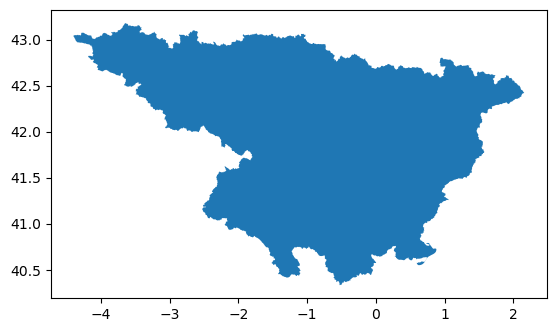

In [3]:
gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()

In [4]:
print(gdf.crs) 

EPSG:4326


In [5]:
# To be used for all the data sources

# bbox = [-31, 27, 40, 81] # Europe
bbox = [-5, 40, 3, 44] # Ebro Basin
time_range = ("2020-01-01", "2021-12-31")

In [4]:
### Land Cover

cci_ds = new_data_store("cciodp")
lc_cci = cci_ds.open_data(
    "esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1", 
    bbox=bbox, 
    time_range=["2015-01-01", "2015-12-31"], # LandCover has different time-range because this is the latest data available via CCI.
)
lc_cci

<xarray.Dataset> Size: 83MB
Dimensions:              (time: 1, lat: 1440, lon: 2880, bnds: 2)
Coordinates:
  * lat                  (lat) float32 6kB 44.0 44.0 43.99 ... 40.01 40.0 40.0
  * lon                  (lon) float32 12kB -4.999 -4.996 -4.993 ... 2.996 2.999
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    crs                  float64 8B ...
    current_pixel_state  (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform...
    date_created:            2025-08-26T09:28:59.833934
    processing_level:        L4
    time_coverage_start:     2015-01-01T00:00:00
    time_coverage_end:       2016-01-01T00:00:00
    time_coverage_duration:  P365DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

CPU times: user 103 ms, sys: 41.8 ms, total: 144 ms
Wall time: 8.81 s


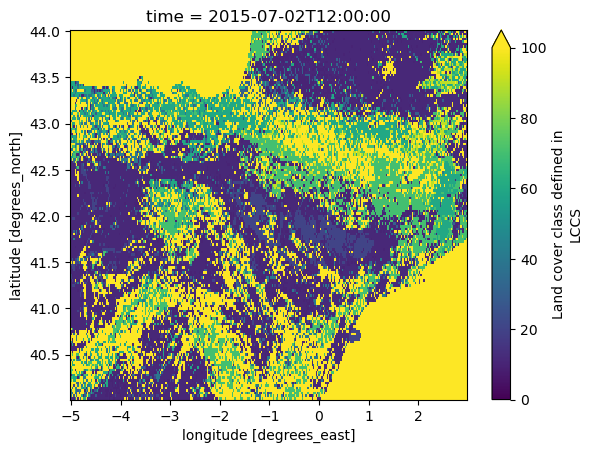

In [6]:
%%time
downsampled_cube = lc_cci.lccs_class.isel(
    lat=slice(None, None, 10),
    lon=slice(None, None, 10),
)
downsampled_cube.plot(vmin=0, vmax=100)

In [7]:
# ERA5

cds_store = new_data_store("cds", normalize_names=True)

data_id = 'reanalysis-era5-land'
variables = ("soil_temperature_level_1", "potential_evaporation", "total_precipitation", "snowfall")
spatial_res = 0.1

cds_cube = cds_store.open_data(
    data_id,
    cds_store.get_data_opener_ids()[0],
    variable_names=variables,
    bbox=bbox,
    spatial_res=spatial_res,
    time_range=time_range
)

xcube-cds version 1.1.0.dev0
2025-08-11 15:02:06,879 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-11 15:02:07,160 INFO Request ID is 32fe8a6b-3575-4e87-86ff-d96a05c56b62
INFO:ecmwf.datastores.legacy_client:Request ID is 32fe8a6b-3575-4e87-86ff-d96a05c56b62
2025-08-11 15:02:07,234 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-11 15:02:20,963 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


ecd195d4c39d621412105912c31c822c.zip:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

In [8]:
cds_cube

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 744, lat: 40, lon: 80)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    expver   (time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-08T09:35 GRIB to CDM+CF via cfgrib-0.9.1...

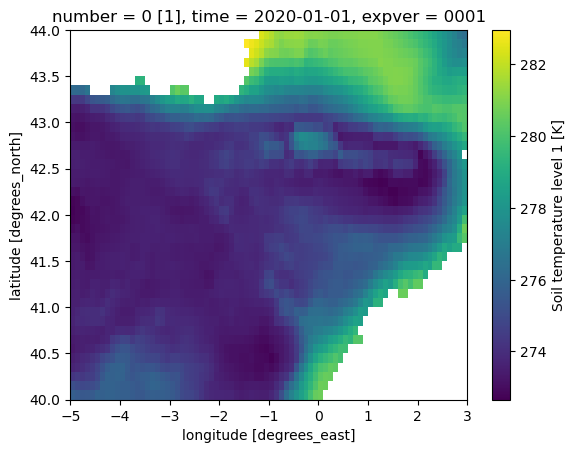

In [9]:
cds_cube.isel(time=0).stl1.plot()

In [5]:
time_range = ('2020-01-01', '2020-03-30')
time_range

('2020-01-01', '2020-03-30')

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
%%time
# CLMS

json_file_path = "credentials.json"
with open(json_file_path, "r") as j:
    credentials = json.loads(j.read())

CPU times: user 1.19 ms, sys: 33 μs, total: 1.22 ms
Wall time: 9.74 ms


In [12]:
clms_data_store = new_data_store("clms", credentials=credentials)

In [13]:
clms_ds = new_data_store("file", root="clms")

In [14]:
import logging
logging.getLogger().setLevel(logging.WARNING)
LOG = logging.getLogger("xcube.clms")
LOG.handlers.clear() 
LOG.setLevel(logging.DEBUG)

handler = logging.StreamHandler()
handler.setLevel(logging.DEBUG)
handler.setFormatter(logging.Formatter(
    "%(asctime)s [%(levelname)s] %(name)s: %(message)s"
))
LOG.addHandler(handler)

In [15]:
%%time
clms_data = clms_data_store.open_data("daily-surface-soil-moisture-v1.0", time_range=time_range)

2025-08-28 15:38:02,105 [DEBUG] xcube.clms: Token expired or not present. Refreshing token.
2025-08-28 15:38:02,175 [DEBUG] xcube.clms: Making a request to https://land.copernicus.eu/@@oauth2-token
2025-08-28 15:38:02,554 [DEBUG] xcube.clms: Token refreshed successfully.
2025-08-28 15:38:02,556 [DEBUG] xcube.clms: Token expired or not present. Refreshing token.
2025-08-28 15:38:02,609 [DEBUG] xcube.clms: Making a request to https://land.copernicus.eu/@@oauth2-token
2025-08-28 15:38:02,829 [DEBUG] xcube.clms: Token refreshed successfully.
2025-08-28 15:38:02,830 [DEBUG] xcube.clms: Current token valid. Reusing it.
2025-08-28 15:38:02,831 [DEBUG] xcube.clms: Making a request to https://land.copernicus.eu/api/@get-download-file-urls/?dataset_uid=c073cf8a1d594593bc5d2f9024f0dc60&download_information_id=0524bf44-6624-4e94-b88a-38af27388b31&date_from=2014-01-01&date_to=2025-08-28
2025-08-28 15:38:04,016 [DEBUG] xcube.clms: Processing 729 files in batches of 20
2025-08-28 15:38:04,017 [DEBUG]

CPU times: user 1min 14s, sys: 13.1 s, total: 1min 27s
Wall time: 23min 18s


In [16]:
clms_data

<xarray.Dataset> Size: 165GB
Dimensions:    (time: 729, lat: 4144, lon: 6832)
Coordinates:
  * lat        (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon        (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
  * time       (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs        (time) |S1 729B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    ssm        (time, lat, lon) float32 83GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
    ssm_noise  (time, lat, lon) float32 83GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [17]:
import pandas as pd

time = clms_data.time.to_index()

full_range = pd.date_range(start=time.min(), end=time.max(), freq=pd.infer_freq(time))

missing = full_range.difference(time)
print(missing)

DatetimeIndex(['2020-07-18', '2021-05-31'], dtype='datetime64[ns]', freq=None)


In [26]:
from dask.distributed import Client, LocalCluster
import xarray as xr

cluster = LocalCluster(n_workers=1, threads_per_worker=1)
client = Client(cluster)
print(client)

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40141 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40691' processes=1 threads=1, memory=30.12 GiB>


In [31]:
client.shutdown()

In [34]:
import dask
dask.config.set(scheduler="threads", num_workers=2)

In [19]:
clms_ssm_only = clms_data.drop_vars("ssm_noise") 

In [29]:
clms_ssm_only

<xarray.Dataset> Size: 83GB
Dimensions:  (time: 729, lat: 4144, lon: 6832)
Coordinates:
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs      (time) |S1 729B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b'' b''
    ssm      (time, lat, lon) float32 83GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [21]:
clms_ds = new_data_store("file", root="input2years")

In [35]:
clms_ds.write_data(clms_ssm_only, f"clms2.zarr")

'clms2.zarr'

In [36]:
dask.config.set(scheduler="threads", num_workers=4)

In [37]:
clms_ds.write_data(clms_ssm_only, f"clms3.zarr")

'clms3.zarr'

In [28]:
%%time
from zappend.api import zappend

config = {
    "target_dir": "input2years/clms_zappend2.zarr",
    "force_new": True,
    "logging": True,
    "slice_engine": "h5netcdf",
}
zappend([clms_ssm_only], config=config)

2025-08-28 17:34:06,150 WARNING Setting 'force_new' is enabled. This will permanently delete existing targets (no rollback).
2025-08-28 17:34:06,153 INFO Processing in-memory slice dataset #0
2025-08-28 17:34:06,155 INFO Creating target dataset input2years/clms_zappend2.zarr
/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/zappend/processor.py:151: FutureWarning: zarr_version is deprecated, use zarr_format
  target_ds.to_zarr(
2025-08-28 17:34:10,536 - distributed.protocol.pickle - ERROR - Failed to serialize 429, message='Too Many Requests', url='https://globalland.vito.be/download/netcdf/surface_soil_moisture/ssm_1km_v1_daily/2021/20210217/c_gls_SSM1km_202102170000_CEURO_S1CSAR_V1.1.1.nc'.
Traceback (most recent call last):
  File "/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 211, in _acquire_with_cache_info
    file = self._cache[self._key]
           

CPU times: user 2.89 s, sys: 121 ms, total: 3.01 s
Wall time: 4.66 s


Exception: ClientResponseError(RequestInfo(url=URL('https://globalland.vito.be/download/netcdf/surface_soil_moisture/ssm_1km_v1_daily/2021/20210217/c_gls_SSM1km_202102170000_CEURO_S1CSAR_V1.1.1.nc'), method='GET', headers=<CIMultiDictProxy('Host': 'globalland.vito.be', 'Range': 'bytes=0-47', 'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br', 'User-Agent': 'Python/3.12 aiohttp/3.12.15')>, real_url=URL('https://globalland.vito.be/download/netcdf/surface_soil_moisture/ssm_1km_v1_daily/2021/20210217/c_gls_SSM1km_202102170000_CEURO_S1CSAR_V1.1.1.nc')), (), status=429, message='Too Many Requests', headers=<CIMultiDictProxy('Server': 'BigIP', 'Connection': 'Keep-Alive', 'Content-Length': '407')>)

In [32]:
clms_ssm_only.to_zarr("clms_ssm_only.zarr")

KeyboardInterrupt: 

2025-08-28 14:00:16,156 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/distributed/worker.py", line 1267, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
         

In [6]:
tds = new_data_store("file", root="input2years")

In [7]:
tds.list_data_ids()

['clms.zarr',
 'soil_moisture_filled.zarr',
 'era5.zarr',
 'landcover2020global.zarr']

In [8]:
clms_data = tds.open_data("clms.zarr")
lc = tds.open_data("landcover2020global.zarr")
cds_cube = tds.open_data("era5.zarr")

In [7]:
%%time
clms_data = clms_data.sel(lat=slice(44, 40), lon=slice(-5, 3))

CPU times: user 5.25 ms, sys: 892 μs, total: 6.14 ms
Wall time: 14.3 ms


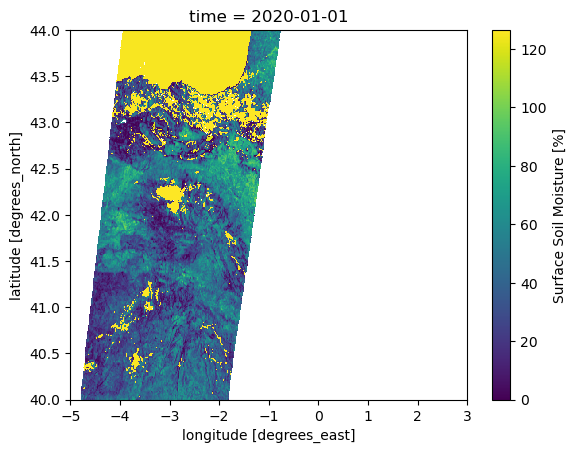

In [10]:
# clms_data.isel(time=0, lat=slice(None, None, 50), lon=slice(None, None, 50)).ssm.plot()
clms_data.isel(time=0).ssm.plot()

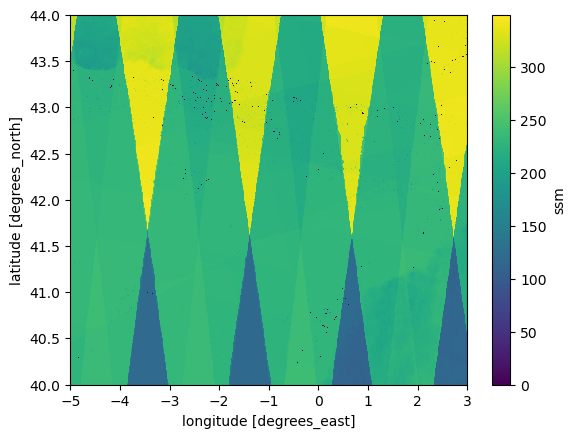

In [11]:
clms_data.ssm.count(dim='time').plot()

## Preprocessing

### Soil Moisture (CLMS) - Interpolation

In [8]:
def swicomp_nan(in_data, in_jd, ctime=2):
    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    if len(ID[0]) == 0:
        return filtered

    D = in_jd[ID]
    SWI = in_data[ID].copy()
    tdiff = np.diff(D)

    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI
    return filtered

In [9]:
julian_dates = xr.DataArray(
    pd.to_datetime(clms_data.time.values).to_julian_date().values,
    dims='time',
    coords={'time': clms_data.time}
)
julian_dates

<xarray.DataArray (time: 729)> Size: 6kB
array([2458849.5, 2458850.5, 2458851.5, 2458852.5, 2458853.5, 2458854.5,
       2458855.5, 2458856.5, 2458857.5, 2458858.5, 2458859.5, 2458860.5,
       2458861.5, 2458862.5, 2458863.5, 2458864.5, 2458865.5, 2458866.5,
       2458867.5, 2458868.5, 2458869.5, 2458870.5, 2458871.5, 2458872.5,
       2458873.5, 2458874.5, 2458875.5, 2458876.5, 2458877.5, 2458878.5,
       2458879.5, 2458880.5, 2458881.5, 2458882.5, 2458883.5, 2458884.5,
       2458885.5, 2458886.5, 2458887.5, 2458888.5, 2458889.5, 2458890.5,
       2458891.5, 2458892.5, 2458893.5, 2458894.5, 2458895.5, 2458896.5,
       2458897.5, 2458898.5, 2458899.5, 2458900.5, 2458901.5, 2458902.5,
       2458903.5, 2458904.5, 2458905.5, 2458906.5, 2458907.5, 2458908.5,
       2458909.5, 2458910.5, 2458911.5, 2458912.5, 2458913.5, 2458914.5,
       2458915.5, 2458916.5, 2458917.5, 2458918.5, 2458919.5, 2458920.5,
       2458921.5, 2458922.5, 2458923.5, 2458924.5, 2458925.5, 2458926.5,
       2458927.5, 2458928.5, 2458929.5, 2458930.5, 2458931.5, 2458932.5,
       2458933.5, 2458934.5, 2458935.5, 2458936.5, 2458937.5, 2458938.5,
       2458939.5, 2458940.5, 2458941.5, 2458942.5, 2458943.5, 2458944.5,
       2458945.5, 2458946.5, 2458947.5, 2458948.5, 2458949.5, 2458950.5,
       2458951.5, 2458952.5, 2458953.5, 2458954.5, 2458955.5, 2458956.5,
       2458957.5, 2458958.5, 2458959.5, 2458960.5, 2458961.5, 2458962.5,
       2458963.5, 2458964.5, 2458965.5, 2458966.5, 2458967.5, 2458968.5,
...
       2459463.5, 2459464.5, 2459465.5, 2459466.5, 2459467.5, 2459468.5,
       2459469.5, 2459470.5, 2459471.5, 2459472.5, 2459473.5, 2459474.5,
       2459475.5, 2459476.5, 2459477.5, 2459478.5, 2459479.5, 2459480.5,
       2459481.5, 2459482.5, 2459483.5, 2459484.5, 2459485.5, 2459486.5,
       2459487.5, 2459488.5, 2459489.5, 2459490.5, 2459491.5, 2459492.5,
       2459493.5, 2459494.5, 2459495.5, 2459496.5, 2459497.5, 2459498.5,
       2459499.5, 2459500.5, 2459501.5, 2459502.5, 2459503.5, 2459504.5,
       2459505.5, 2459506.5, 2459507.5, 2459508.5, 2459509.5, 2459510.5,
       2459511.5, 2459512.5, 2459513.5, 2459514.5, 2459515.5, 2459516.5,
       2459517.5, 2459518.5, 2459519.5, 2459520.5, 2459521.5, 2459522.5,
       2459523.5, 2459524.5, 2459525.5, 2459526.5, 2459527.5, 2459528.5,
       2459529.5, 2459530.5, 2459531.5, 2459532.5, 2459533.5, 2459534.5,
       2459535.5, 2459536.5, 2459537.5, 2459538.5, 2459539.5, 2459540.5,
       2459541.5, 2459542.5, 2459543.5, 2459544.5, 2459545.5, 2459546.5,
       2459547.5, 2459548.5, 2459549.5, 2459550.5, 2459551.5, 2459552.5,
       2459553.5, 2459554.5, 2459555.5, 2459556.5, 2459557.5, 2459558.5,
       2459559.5, 2459560.5, 2459561.5, 2459562.5, 2459563.5, 2459564.5,
       2459565.5, 2459566.5, 2459567.5, 2459568.5, 2459569.5, 2459570.5,
       2459571.5, 2459572.5, 2459573.5, 2459574.5, 2459575.5, 2459576.5,
       2459577.5, 2459578.5, 2459579.5])
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [10]:
clms_data_chunked = clms_data.chunk({'time': -1})
sm_filled = clms_data_chunked['ssm'].interpolate_na(dim='time', method='linear') #, fill_value="extrapolate") ?
sm_filled

<xarray.DataArray 'ssm' (time: 729, lat: 448, lon: 896)> Size: 2GB
dask.array<transpose, shape=(729, 448, 896), dtype=float64, chunksize=(729, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Attributes:
    Class:          DATA
    flag_meanings:  ExceedingMin ExceedingMax WaterMask SensitivityMask Slope...
    flag_values:    [241, 242, 251, 252, 253]
    grid_mapping:   crs
    long_name:      Surface Soil Moisture
    units:          %
    valid_range:    [0, 200]

In [11]:
sm_clipped = sm_filled.clip(max=100)
sm_normalized = (sm_clipped - sm_clipped.min()) / (sm_clipped.max() - sm_clipped.min())
sm_normalized

<xarray.DataArray 'ssm' (time: 729, lat: 448, lon: 896)> Size: 2GB
dask.array<truediv, shape=(729, 448, 896), dtype=float64, chunksize=(729, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [12]:
SWI = xr.apply_ufunc(
    swicomp_nan,
    sm_normalized,       
    julian_dates,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized", 
    kwargs={"ctime": 2},
    output_dtypes=[clms_data.ssm.dtype]
)

In [13]:
SWI

<xarray.DataArray (lat: 448, lon: 896, time: 729)> Size: 2GB
dask.array<transpose, shape=(448, 896, 729), dtype=float64, chunksize=(448, 896, 729), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

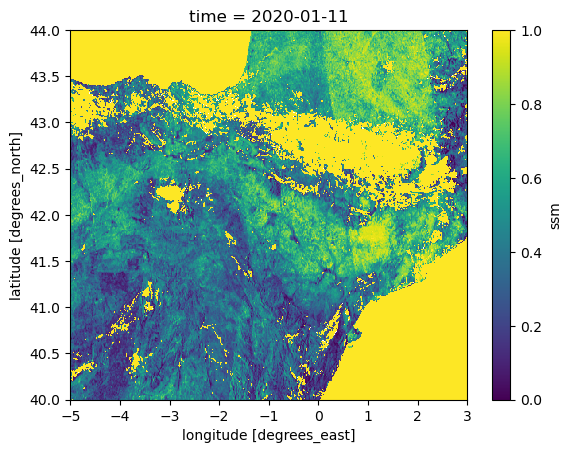

In [19]:
sm_normalized.isel(time=10).plot()

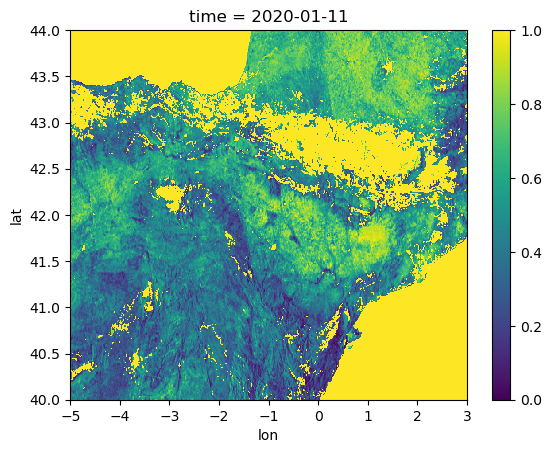

In [20]:
SWI.isel(time=10).plot()

In [22]:
SWI = chunk_dataset(SWI, chunk_sizes={"time":1})
SWI

<xarray.DataArray (lat: 448, lon: 896, time: 729)> Size: 2GB
dask.array<rechunk-merge, shape=(448, 896, 729), dtype=float64, chunksize=(448, 896, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [23]:
clms_data["SWI"] = SWI.transpose("time", "lat", "lon")

In [24]:
clms_data

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 729, lat: 448, lon: 896)
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs      (time) |S1 729B dask.array<chunksize=(729,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    SWI      (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [25]:
%%time
tds.write_data(clms_data, "soil_moisture_filled.zarr")

CPU times: user 8min 25s, sys: 17.2 s, total: 8min 42s
Wall time: 7min 3s


'soil_moisture_filled.zarr'

In [9]:
soil_moisture = tds.open_data("soil_moisture_filled.zarr")

In [9]:
soil_moisture

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 729, lat: 448, lon: 896)
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    SWI      (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs      (time) |S1 729B dask.array<chunksize=(729,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [ ]:
soil_moisture["sm_filled"].attrs["long_name"] = "Gap-filled soil moisture"

In [ ]:
viewer.add_dataset(soil_moisture)

In [ ]:
viewer.info()

In [ ]:
viewer.show()

In [67]:
viewer.stop_server()

INFO:xcube:Stopping service...


In [ ]:
### Mask CDS with LandCover and convert the LC to 0-1 bool

In [10]:
bbox

[-5, 40, 3, 44]

In [21]:
lc_subset = lc.sel(
    lon=slice(-5, 3),
    lat=slice(44, 40)
)
lc_subset

<xarray.Dataset> Size: 50MB
Dimensions:              (lat: 1440, lon: 2880, bounds: 2)
Coordinates:
  * lat                  (lat) float64 12kB 44.0 44.0 43.99 ... 40.01 40.0 40.0
  * lon                  (lon) float64 23kB -4.999 -4.996 -4.993 ... 2.996 2.999
    time                 datetime64[ns] 8B ...
Dimensions without coordinates: bounds
Data variables:
    change_count         (lat, lon) uint8 4MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    crs                  int32 4B ...
    current_pixel_state  (lat, lon) float32 17MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    lat_bounds           (lat, bounds) float64 23kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    lccs_class           (lat, lon) uint8 4MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    lon_bounds           (lon, bounds) float64 46kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
    observation_count    (lat, lon) uint16 8MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    processed_flag       (lat, lon) float32 17MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    time_bounds          (bounds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

In [22]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_subset.lccs_class.where(lc_subset["lccs_class"].isin(keep_classes))
filtered_lc

<xarray.DataArray 'lccs_class' (lat: 1440, lon: 2880)> Size: 17MB
dask.array<where, shape=(1440, 2880), dtype=float32, chunksize=(1440, 1800), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 12kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float64 23kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
    time     datetime64[ns] 8B 2020-01-01
Attributes:
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    valid_max:            220
    valid_min:            1

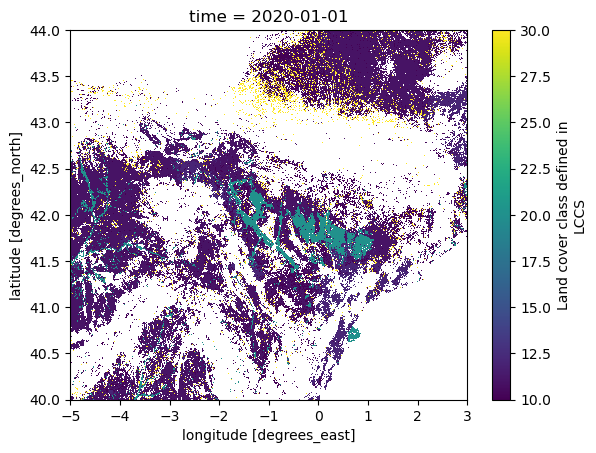

In [23]:
filtered_lc.plot()

In [24]:
keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)
lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")
lc_binary

<xarray.DataArray 'lccs_class' (lat: 1440, lon: 2880)> Size: 4MB
dask.array<astype, shape=(1440, 2880), dtype=uint8, chunksize=(1440, 1800), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 12kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float64 23kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
    time     datetime64[ns] 8B 2020-01-01

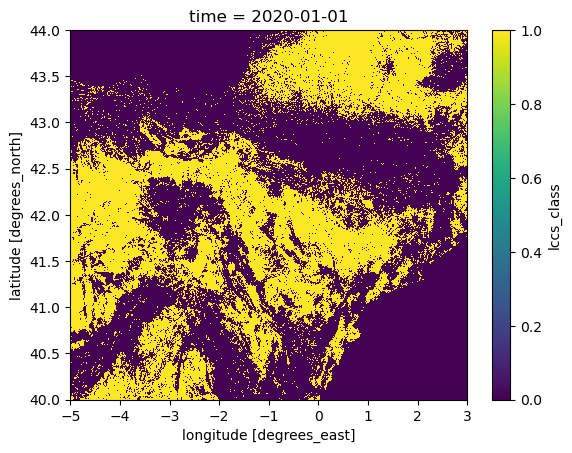

In [25]:
lc_binary.plot()

In [ ]:
# Aggregate ERA5 variables from hourly to daily

In [26]:
stl1_daily = cds_cube["stl1"].resample(time="1D").mean()
pev_daily  = cds_cube["pev"].resample(time="1D").sum()     # different aggregation ? 
tp_daily   = cds_cube["tp"].resample(time="1D").max()
sf_daily   = cds_cube["sf"].resample(time="1D").mean()

cds_cube_daily = xr.merge([stl1_daily, pev_daily, tp_daily, sf_daily])

In [27]:
cds_cube_daily

<xarray.Dataset> Size: 37MB
Dimensions:  (lat: 40, lon: 80, time: 731)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    stl1     (time, lat, lon) float32 9MB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 9MB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 9MB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 9MB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Soil temperature level 1
    standard_name:                            surface_temperature
    units:                                    K

In [ ]:
# Now we resample LC and ERA5 data to Soil moisture grid - 1km

In [28]:
gm_sm = GridMapping.from_dataset(soil_moisture)
gm_sm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [29]:
gm_cds = GridMapping.from_dataset(cds_cube_daily)
gm_cds

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.1, 0.1)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 80, 40)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (80, 40)
* tile_size: (80, 40)

In [30]:
gm_lc = GridMapping.from_dataset(lc_binary.to_dataset(name="lc_binary"))
gm_lc

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777775, 0.002777775)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 2880, 1440)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (2880, 1440)
* tile_size: (1800, 1440)

In [58]:
cds_in_gm_sm = resample_in_space(cds_cube_daily, target_gm = gm_sm)
cds_in_gm_sm = cds_in_gm_sm.assign_coords(time=cds_cube_daily.time) # this step is needed until resample_in_space is fixed
cds_in_gm_sm

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Soil temperature level 1
    standard_name:                            surface_temperature
    units:                                    K

In [33]:
GridMapping.from_dataset(cds_in_gm_sm)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [36]:
lc_binary.attrs['flag_values'] = [0, 1]
lc_binary.attrs['flag_meanings'] = "no_data croplands_land_cover"
lc_in_gm_sm = resample_in_space(lc_binary.to_dataset(name="lc_binary"), target_gm = gm_sm, agg_methods="mode")
lc_in_gm_sm=lc_in_gm_sm.drop_vars('time')
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

In [37]:
GridMapping.from_dataset(lc_in_gm_sm)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

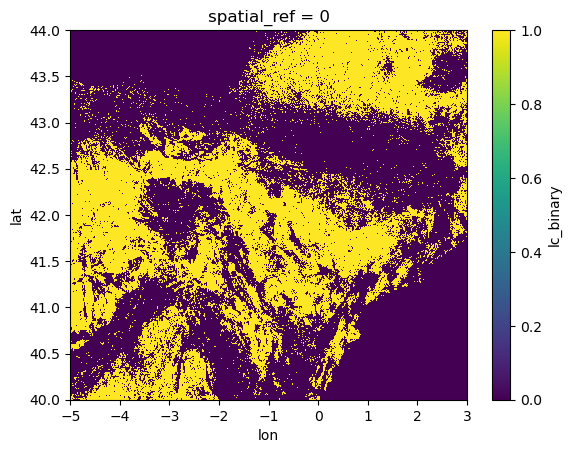

In [38]:
lc_in_gm_sm.lc_binary.plot()

In [59]:
cds_masked_full = cds_in_gm_sm.where(lc_in_gm_sm.lc_binary == 1)
cds_masked = mask_dataset_by_geometry(cds_masked_full, gdf.geometry[0])
cds_masked

<xarray.Dataset> Size: 3GB
Dimensions:      (lon: 736, lat: 320, time: 731)
Coordinates:
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    stl1         (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    pev          (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp           (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf           (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/43)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    geospatial_lat_min:                       40.339285712498786
    geospatial_lat_max:                       43.19642857321242
    geospatial_lat_resolution:                0.008928575
    geospatial_bounds_crs:                    CRS84
    geospatial_bounds:                        POLYGON((-4.410714287500187 40....
    date_modified:                            2025-08-29T16:51:30.021588

In [40]:
soil_moisture_masked_full = soil_moisture.where(lc_in_gm_sm.lc_binary == 1)
soil_moisture_masked = mask_dataset_by_geometry(soil_moisture_masked_full, gdf.geometry[0])
soil_moisture_masked

<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 320, lon: 736, time: 729)
Coordinates:
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    crs          (time, lat, lon) object 1GB dask.array<chunksize=(729, 320, 736), meta=np.ndarray>
    ssm          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-29T16:01:16.923155

In [161]:
soil_moisture_masked.SWI.isel(time=10).plot()

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

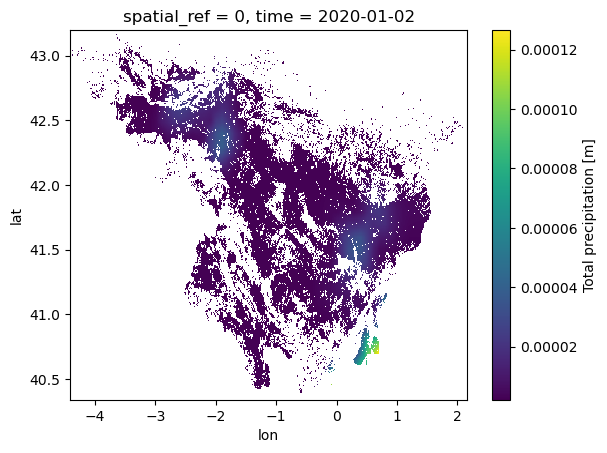

In [60]:
cds_masked.tp.isel(time=1).plot()

In [42]:
def convert_m_to_mm(dataarray, update_long_name=True):
    """
    Convert DataArray values from meters to millimeters.

    Parameters:
    - dataarray: xarray.DataArray, the input data with units in meters.
    - update_long_name: bool, if True, appends '(millimeters)' to long_name attribute.

    Returns:
    - xarray.DataArray with values multiplied by 1000 and updated attributes.
    """
    converted = dataarray * 1000

    converted.attrs = dataarray.attrs.copy()

    converted.attrs['units'] = 'mm'
    converted.attrs['GRIB_units'] = 'mm'
 
    if update_long_name:
        if 'long_name' in converted.attrs:
            converted.attrs['long_name'] = converted.attrs['long_name'] + ' (millimeters)'
        else:
            converted.attrs['long_name'] = 'Potential evaporation (millimeters)'

    return converted


In [61]:
cds_masked["pev"] =  convert_m_to_mm(cds_masked["pev"] * -1) # Making it positive values only
cds_masked["tp"] =  convert_m_to_mm(cds_masked["tp"])
cds_masked

<xarray.Dataset> Size: 3GB
Dimensions:      (lon: 736, lat: 320, time: 731)
Coordinates:
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    stl1         (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    pev          (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp           (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf           (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/43)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    geospatial_lat_min:                       40.339285712498786
    geospatial_lat_max:                       43.19642857321242
    geospatial_lat_resolution:                0.008928575
    geospatial_bounds_crs:                    CRS84
    geospatial_bounds:                        POLYGON((-4.410714287500187 40....
    date_modified:                            2025-08-29T16:51:30.021588

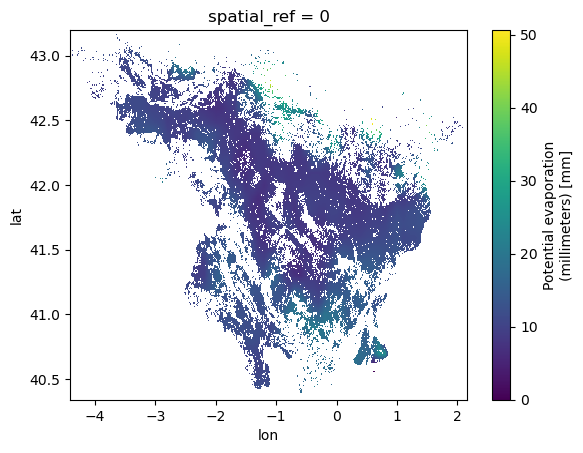

In [44]:
cds_masked.pev.isel(time=0).plot()

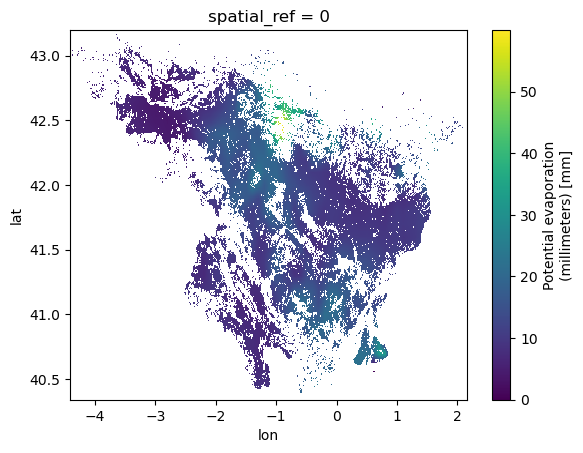

In [45]:
cds_masked.pev.isel(time=3).plot()

In [48]:
soil_moisture_masked

<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 320, lon: 736, time: 729)
Coordinates:
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    crs          (time, lat, lon) object 1GB dask.array<chunksize=(729, 320, 736), meta=np.ndarray>
    ssm          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-29T16:01:16.923155

In [54]:
cds_masked

<xarray.Dataset> Size: 3GB
Dimensions:      (lon: 736, lat: 320, time: 731)
Coordinates:
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
    spatial_ref  int64 8B 0
Dimensions without coordinates: time
Data variables:
    stl1         (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    pev          (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp           (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf           (time, lat, lon) float32 689MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/43)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              surface_temperature
    GRIB_cfVarName:                           stl1
    GRIB_dataType:                            an
    ...                                       ...
    geospatial_lat_min:                       40.339285712498786
    geospatial_lat_max:                       43.19642857321242
    geospatial_lat_resolution:                0.008928575
    geospatial_bounds_crs:                    CRS84
    geospatial_bounds:                        POLYGON((-4.410714287500187 40....
    date_modified:                            2025-08-29T16:01:16.801034

In [52]:
print(len(soil_moisture_masked['time']), len(cds_masked['time']))

729 731


In [ ]:
soil_moisture_aligned, cds_aligned = xr.align(
    soil_moisture_masked,
    cds_masked,
    join="outer" # because SSM does not have data for 2 days
)


In [63]:
soil_moisture_aligned

<xarray.Dataset> Size: 4GB
Dimensions:      (lat: 320, lon: 736, time: 731)
Coordinates:
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    crs          (time, lat, lon) object 1GB dask.array<chunksize=(729, 320, 736), meta=np.ndarray>
    ssm          (time, lat, lon) float64 1GB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-29T16:01:16.923155

In [64]:
ds_combined = xr.merge([soil_moisture_aligned, cds_aligned, lc_in_gm_sm]) 
ds_combined

<xarray.Dataset> Size: 12GB
Dimensions:      (lat: 448, lon: 896, time: 731)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    crs          (time, lat, lon) object 2GB dask.array<chunksize=(729, 320, 896), meta=np.ndarray>
    ssm          (time, lat, lon) float64 2GB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-29T16:01:16.923155

In [65]:
chunked_ds = chunk_dataset(ds_combined, chunk_sizes={"time":1, "lat":448, "lon":896}, format_name="zarr")
chunked_ds

<xarray.Dataset> Size: 12GB
Dimensions:      (lat: 448, lon: 896, time: 731)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs          (time, lat, lon) object 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm          (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-29T16:01:16.923155

In [66]:
tds.write_data(chunked_ds, "irrigation_input.zarr")

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/xcube/core/store/fs/impl/dataset.py:207: SerializationWarning: variable None has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  data.to_zarr(


'irrigation_input.zarr'

In [68]:
irrigation_input=tds.open_data("irrigation_input.zarr")
irrigation_input

<xarray.Dataset> Size: 12GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs          (time, lat, lon) |S8 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm          (time, lat, lon) float64 2GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    date_modified:              2025-08-29T16:01:16.923155
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    ...                         ...
    region_name:                CEURO
    sensor:                     CSAR
    source:                     Derived from EO radar observations
    time_coverage_end:          2020-01-01T23:59:59Z
    time_coverage_start:        2020-01-01T00:00:00Z
    title:                      Daily Surface Soil Moisture 1km: CEURO 2020-0...

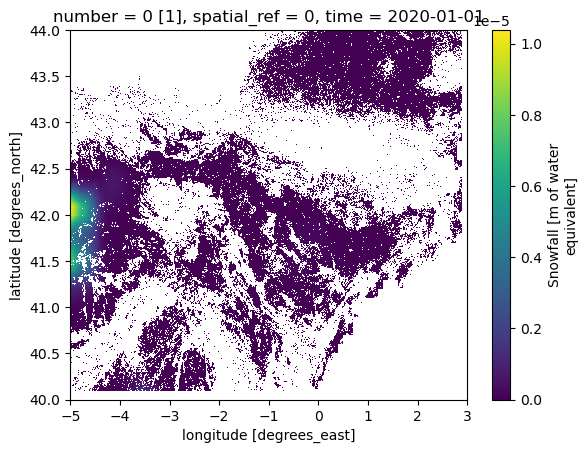

In [197]:
irrigation_input.sf.isel(time=0).plot()

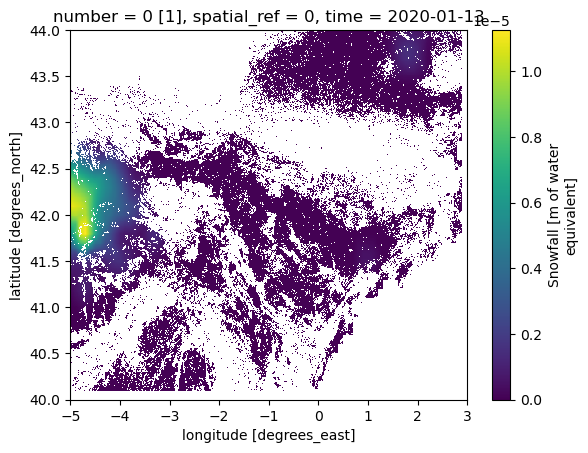

In [198]:
irrigation_input.sf.isel(time=12).plot()

In [184]:
from xcube.webapi.viewer import Viewer
viewer = Viewer()

INFO:xcube:Loaded service API 'auth'
INFO:xcube:Loaded service API 'styles'
INFO:xcube:Loaded service API 'viewer'
INFO:xcube:Loaded service API 'meta'
INFO:xcube:Loaded service API 'places'
INFO:xcube:Loaded service API 'datasets'
INFO:xcube:Loaded service API 'tiles'
INFO:xcube:Loaded service API 'timeseries'
INFO:xcube:Loaded service API 'statistics'
INFO:xcube:Loaded service API 'volumes'
INFO:xcube:Loaded service API 'expressions'
INFO:xcube:Loaded service API 'ows.coverages'
INFO:xcube:Loaded service API 's3'
INFO:xcube:Loaded service API 'ows.stac'
INFO:xcube:Loaded service API 'compute'
INFO:xcube:Loaded service API 'ows.wmts'
DETAIL:xcube:Added route '/viewer/config/{*path}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/state' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/contributions' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/layout/{contribPoint}/{contribIndex}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/callback' from API 'viewer'

In [185]:
viewer.add_dataset(irrigation_input)

'4f1b1c36-0fc8-477b-a5b6-b452f974fafd'

In [223]:
viewer.info()

Server: http://localhost:8002
Viewer: http://localhost:8002/viewer/?serverUrl=http://localhost:8002


In [186]:
viewer.show()

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = masked_lc["lccs_class"].isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()

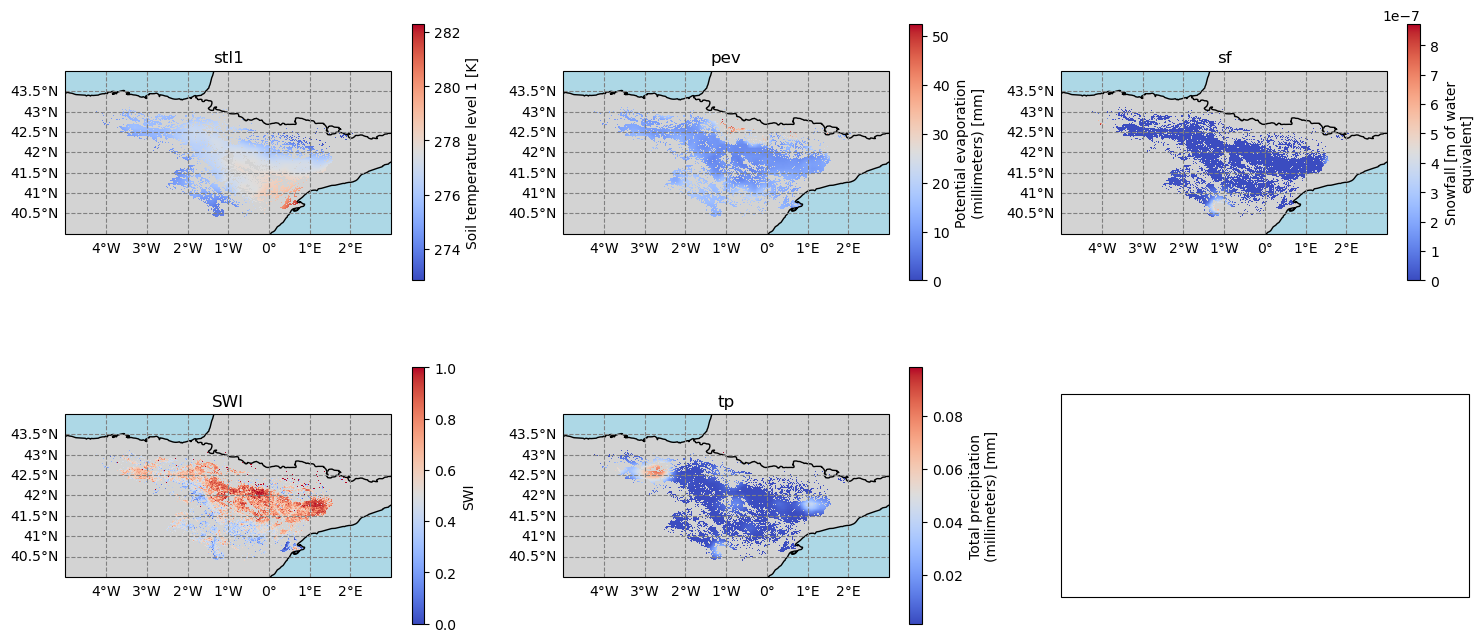

In [69]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = irrigation_input.isel(time=5)
vars_to_plot = ["stl1", "pev", "sf", "SWI", "tp"]

proj = ccrs.PlateCarree()
n_vars = len(vars_to_plot)
n_cols = 3
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    subplot_kw={"projection": proj}
)

for ax, var in zip(axes.flat, vars_to_plot):
    da = ds[var]
    da.plot(ax=ax, transform=proj, cmap="coolwarm", cbar_kwargs={"shrink": 0.6})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.set_title(var)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False

# for ax in axes.flat[n_vars:]:
#     ax.set_visible(False)

plt.tight_layout()
plt.show()


In [219]:
irrigation_input

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [221]:
irrigation_input.tp.sum(dim="time", skipna=True).compute()

<xarray.DataArray 'tp' (lat: 448, lon: 896)> Size: 2MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(448, 896), dtype=float32)
Coordinates:
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B 0
    spatial_ref  int64 8B 0

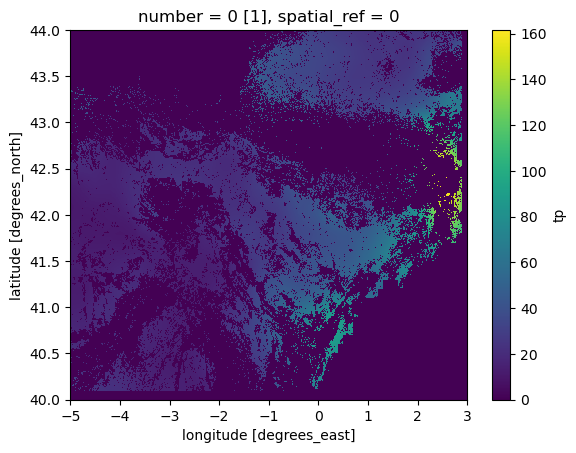

In [222]:
irrigation_input.tp.sum(dim="time", skipna=True).compute().plot()

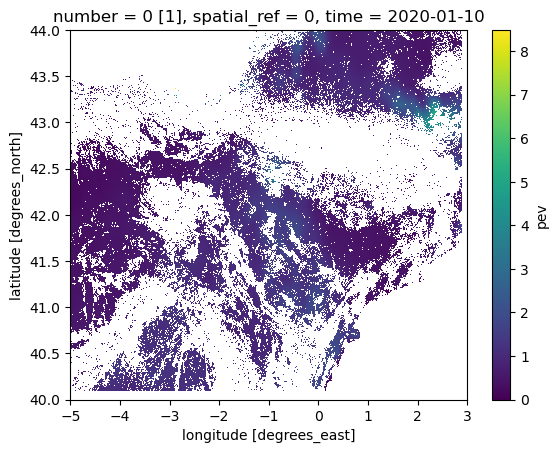

In [229]:
irrigation_input["pev"] = irrigation_input["pev"] * -1
irrigation_input.pev.isel(time=9).plot()

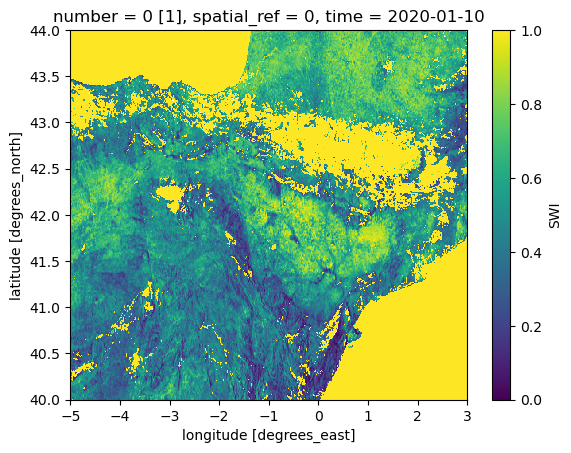

In [230]:
irrigation_input.SWI.isel(time=9).plot()

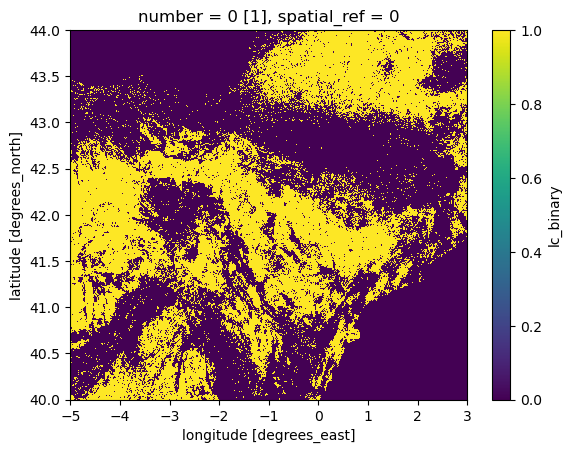

In [232]:
irrigation_input.lc_binary.plot()

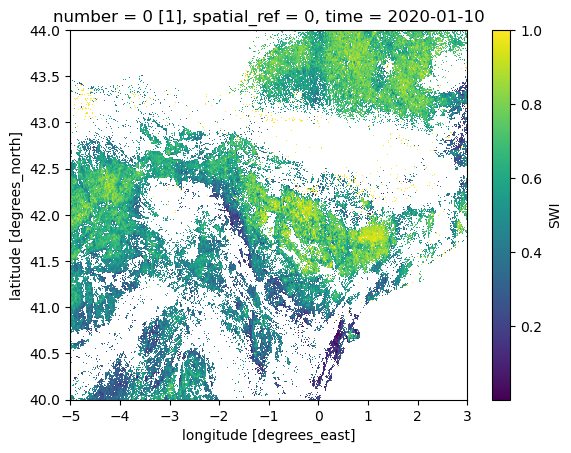

In [233]:
irrigation_input["SWI"] = irrigation_input["SWI"].where(irrigation_input.lc_binary == 1)
irrigation_input.SWI.isel(time=9).plot()

In [ ]:
irrigation_input

In [234]:
fsd.write_data(irrigation_input, "irrigation_input_final.zarr")

'irrigation_input_final.zarr'

In [227]:
irrigation_input.lc_binary

<xarray.DataArray 'lc_binary' (lat: 448, lon: 896)> Size: 401kB
dask.array<open_dataset-lc_binary, shape=(448, 896), dtype=uint8, chunksize=(448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number       int64 8B ...
    spatial_ref  int64 8B ...
Attributes:
    flag_meanings:  no_data croplands_land_cover
    flag_values:    [0, 1]
    grid_mapping:   spatial_ref

In [225]:
irrigation_input

<xarray.Dataset> Size: 548MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(1,), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

# TODO:
- Change the sign for pev to positive (mulitply by -1)
- SWI - filter again using LC

In [205]:
GridMapping.from_dataset(irrigation_input)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [207]:
0.008928575*111.32

0.9939289689999998